# Treatment effect in an RCT under increasing misspecification

The motivating scenario is the kind of trial the `mcount` authors built
`mznib` for: a digital-reminder intervention to improve medication
adherence, where the outcome is the number of days a subject opened
their pill bottle out of `N = 30` study days. The trial reports an
intent-to-treat effect on adherence; the analyst's job is to recover
that effect from a count outcome that is bounded `[0, N]`, has many
zeros (subjects who never engage), and a lump at `N` (perfect
adherers).

Truth in this notebook:

- Control adherence (latent success rate) `p_ctl = 0.40`
- Treatment adherence `p_tx = 0.55` — a **25%-ish lift in adherence**
  on the latent scale (logit effect ≈ 0.61)
- Structural zeros `π_0 = 0.10`, structural `N` `π_N = 0.05`, equal
  across arms in the matched stage
- `N = 30`, 300 subjects per arm

That gives marginal adherence proportions of about **0.39 in control**
and **0.52 in treatment** — an absolute risk difference of ~0.13 days
per 30, i.e. about a 33% relative increase in observed adherence.

## Methods compared at each stage

| Method | What it models | Inference |
|---|---|---|
| Naive Binomial GLM | `logit(p_naive) = α + β·tx`, ignoring inflation | MLE + Wald |
| `mcount::mznib`    | `logit(E[y/N]) = α + β·tx` (marginal) | MLE + bootstrap |
| NumPyro ZNI-Bin    | `logit(p_latent) = α + β·tx`, separate `π_0`, `π_N` | NUTS posterior |

Estimands the user actually cares about for an RCT:

- **Absolute risk difference on adherence**: `E[y/N | tx=1] − E[y/N | tx=0]`
- **Latent treatment effect**: `logit p_tx − logit p_ctl` (only the
  ZNI models can give this cleanly)

The four stages below progressively break the assumptions of the
matched ZNI-Binomial.

In [1]:
import numpy as np, pandas as pd, jax
import matplotlib.pyplot as plt

from zni_rct import (
    simulate_rct_matched, simulate_rct_inflation_shift,
    simulate_rct_heterogeneous, simulate_rct_overdisp,
    fit_naive, fit_numpyro, summarise,
)

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
pandas2ri.activate()
ro.r('suppressPackageStartupMessages(library(mcount))')

np.set_printoptions(precision=3, suppress=True)

## 1. Helpers

Each method returns the same quantities so we can build a comparison
table:

- `tx_logit_mean`, `tx_logit_ci`  – effect on the model's logit scale
- `em_ctl`, `em_tx`               – predicted marginal `E[y/N]` per arm
- `em_diff_mean`, `em_diff_ci`    – predicted absolute risk difference

In [2]:
N = 30


def _delta_method_diff(intercept, beta, se_int, se_beta, cov_int_beta=0.0):
    """Marginal diff sigmoid(a+b) - sigmoid(a) with delta-method SE."""
    p0 = 1.0 / (1.0 + np.exp(-intercept))
    p1 = 1.0 / (1.0 + np.exp(-(intercept + beta)))
    diff = p1 - p0
    da = p1 * (1 - p1) - p0 * (1 - p0)
    db = p1 * (1 - p1)
    var = da**2 * se_int**2 + db**2 * se_beta**2 + 2 * da * db * cov_int_beta
    se = float(np.sqrt(max(var, 0.0)))
    return diff, (diff - 1.96 * se, diff + 1.96 * se), p0, p1


def fit_naive_full(y, tx, N):
    f = fit_naive(y, tx, N)
    diff, ci, p0, p1 = _delta_method_diff(
        f['intercept'], f['tx'], se_int=f['tx_se'], se_beta=f['tx_se']
    )
    return {
        'method': 'naive GLM',
        'tx_logit_mean': f['tx'], 'tx_logit_ci': f['tx_ci'],
        'em_ctl': p0, 'em_tx': p1,
        'em_diff_mean': diff, 'em_diff_ci': ci,
    }


def fit_mznib_full(y, tx, N):
    df = pd.DataFrame({
        'y': y.astype(int),
        'tx': tx.astype(int),
        'N_i': np.full(len(y), N, dtype=int),
    })
    ro.globalenv['df'] = df
    ro.r('fit <- mznib(y ~ tx, data=df, N_i=df$N_i, R=300, seed=1L)')
    ic   = float(ro.r('fit$coef$estimate[1]')[0])
    eff  = float(ro.r('fit$coef$estimate[2]')[0])
    se   = float(ro.r('fit$coef$SE[2]')[0])
    cilo = float(ro.r('fit$coef$CI_lower[2]')[0])
    cihi = float(ro.r('fit$coef$CI_upper[2]')[0])
    p0 = 1.0 / (1.0 + np.exp(-ic))
    p1 = 1.0 / (1.0 + np.exp(-(ic + eff)))
    # Bootstrap-based CI on the marginal diff using mznib's own bootstrap reps:
    alpha = np.asarray(ro.r('fit$alpha_estimates'))   # (R, k)
    p0_b = 1.0 / (1.0 + np.exp(-alpha[:, 0]))
    p1_b = 1.0 / (1.0 + np.exp(-(alpha[:, 0] + alpha[:, 1])))
    diff_b = p1_b - p0_b
    return {
        'method': 'mcount::mznib',
        'tx_logit_mean': eff, 'tx_logit_ci': (cilo, cihi),
        'em_ctl': p0, 'em_tx': p1,
        'em_diff_mean': float(diff_b.mean()),
        'em_diff_ci': (float(np.quantile(diff_b, 0.025)),
                       float(np.quantile(diff_b, 0.975))),
    }


def fit_numpyro_full(y, tx, N, key=0):
    out = fit_numpyro(y, tx, N, key=key)
    return {
        'method': 'NumPyro ZNI',
        'tx_logit_mean': float(out['tx_logit'].mean()),
        'tx_logit_ci': (float(np.quantile(out['tx_logit'], 0.025)),
                        float(np.quantile(out['tx_logit'], 0.975))),
        'em_ctl': float(out['em_ctl'].mean()),
        'em_tx':  float(out['em_tx'].mean()),
        'em_diff_mean': float(out['em_diff'].mean()),
        'em_diff_ci': (float(np.quantile(out['em_diff'], 0.025)),
                       float(np.quantile(out['em_diff'], 0.975))),
        '_post': out,
    }


def fit_all(y, tx, N, key=0):
    return [fit_naive_full(y, tx, N),
            fit_mznib_full(y, tx, N),
            fit_numpyro_full(y, tx, N, key=key)]

## 2. Stage 1 — matched ZNI-Binomial

Treatment shifts only the latent `p`. All three methods should recover
the marginal effect; the ZNI models should additionally pin down `π_0`
and `π_N` correctly, and the NumPyro model should recover the latent
logit-effect of ~0.61. The naive GLM's logit estimate is on a *different*
scale (the marginal), so its number is not directly comparable.

In [3]:
truths_marginal = []  # filled in per stage

stages = [
    ("Stage 1: matched ZNIB", simulate_rct_matched, {}),
    ("Stage 2: tx also lowers π_0",
        simulate_rct_inflation_shift, dict(pi0_ctl=0.20, pi0_tx=0.05)),
    ("Stage 3: 50% non-responders",
        simulate_rct_heterogeneous, dict(p_tx_responder=0.75, p_tx_nonresp=0.40, prop_resp=0.5)),
    ("Stage 4: subject-level overdispersion",
        simulate_rct_overdisp, dict(kappa=4.0)),
]

results = []
for i, (name, sim, kwargs) in enumerate(stages):
    rng = np.random.default_rng(100 + i)
    y, tx = sim(rng, **kwargs)
    em_ctl_emp = (y[tx == 0] / N).mean()
    em_tx_emp  = (y[tx == 1] / N).mean()
    truth_diff = em_tx_emp - em_ctl_emp
    truths_marginal.append(truth_diff)
    print(f"=== {name} ===")
    print(f"  empirical E[y/N]  control={em_ctl_emp:.3f}  treated={em_tx_emp:.3f}  diff={truth_diff:.3f}")
    fits = fit_all(y, tx, N, key=i)
    for f in fits:
        print(f"  {f['method']:>14} | logit β = {f['tx_logit_mean']:+.3f} "
              f"[{f['tx_logit_ci'][0]:+.3f}, {f['tx_logit_ci'][1]:+.3f}] | "
              f"diff E[y/N] = {f['em_diff_mean']:+.3f} "
              f"[{f['em_diff_ci'][0]:+.3f}, {f['em_diff_ci'][1]:+.3f}]")
    results.append((name, fits, em_ctl_emp, em_tx_emp))
    print()

=== Stage 1: matched ZNIB ===
  empirical E[y/N]  control=0.384  treated=0.523  diff=0.139


       naive GLM | logit β = +0.563 [+0.517, +0.610] | diff E[y/N] = +0.139 [+0.127, +0.150]
   mcount::mznib | logit β = +0.564 [+0.440, +0.687] | diff E[y/N] = +0.140 [+0.110, +0.169]
     NumPyro ZNI | logit β = +0.648 [+0.583, +0.717] | diff E[y/N] = +0.140 [+0.126, +0.155]

=== Stage 2: tx also lowers π_0 ===
  empirical E[y/N]  control=0.364  treated=0.577  diff=0.214


       naive GLM | logit β = +0.871 [+0.811, +0.931] | diff E[y/N] = +0.214 [+0.199, +0.228]
   mcount::mznib | logit β = +0.871 [+0.756, +0.992] | diff E[y/N] = +0.214 [+0.186, +0.242]
     NumPyro ZNI | logit β = +0.588 [+0.524, +0.653] | diff E[y/N] = +0.122 [+0.108, +0.136]

=== Stage 3: 50% non-responders ===
  empirical E[y/N]  control=0.362  treated=0.533  diff=0.171


       naive GLM | logit β = +0.700 [+0.640, +0.759] | diff E[y/N] = +0.171 [+0.156, +0.186]
   mcount::mznib | logit β = +0.700 [+0.554, +0.854] | diff E[y/N] = +0.172 [+0.137, +0.208]
     NumPyro ZNI | logit β = +0.719 [+0.653, +0.786] | diff E[y/N] = +0.150 [+0.135, +0.165]

=== Stage 4: subject-level overdispersion ===
  empirical E[y/N]  control=0.392  treated=0.554  diff=0.162


       naive GLM | logit β = +0.655 [+0.596, +0.715] | diff E[y/N] = +0.162 [+0.147, +0.177]
   mcount::mznib | logit β = +0.655 [+0.471, +0.842] | diff E[y/N] = +0.162 [+0.118, +0.206]
     NumPyro ZNI | logit β = +0.689 [+0.625, +0.757] | diff E[y/N] = +0.142 [+0.128, +0.157]



## 3. Forest plot — marginal absolute risk difference

The estimand `E[y/N | tx=1] − E[y/N | tx=0]` is the headline trial
result: percentage-point increase in adherence days. Black `×` marks
the empirical difference (the answer the trial would publish before
modelling). All three methods should sit close to it when correctly
specified.

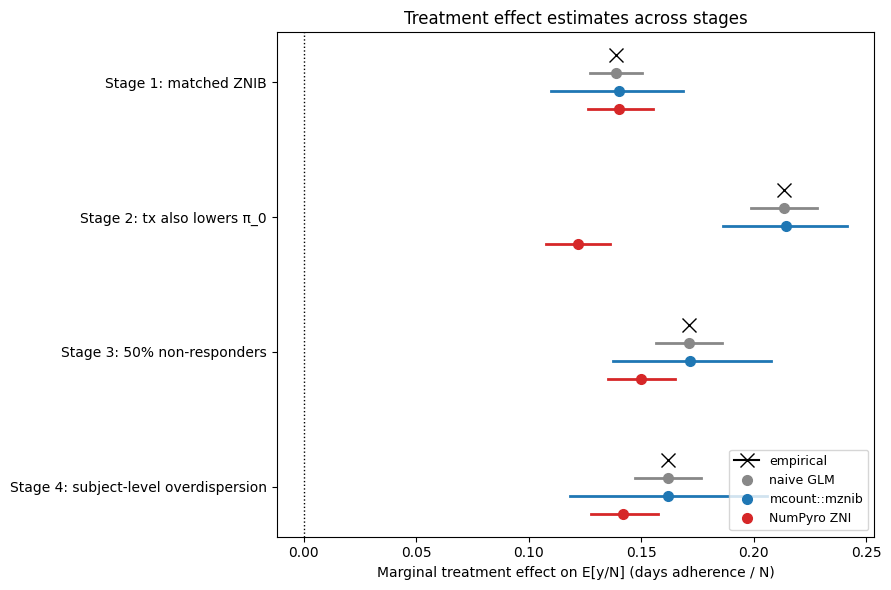

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))
method_colors = {
    'naive GLM':       '#888888',
    'mcount::mznib':   '#1f77b4',
    'NumPyro ZNI':     '#d62728',
}
y_pos = 0
ytick_pos, ytick_labels = [], []

for stage_idx, (name, fits, em_c, em_t) in enumerate(results):
    truth = em_t - em_c
    ax.axvspan(truth - 0.001, truth + 0.001, alpha=0)  # placeholder
    ax.plot(truth, y_pos + 1, marker='x', color='black', markersize=10,
            zorder=5, label='empirical' if stage_idx == 0 else None)
    for j, f in enumerate(fits):
        col = method_colors[f['method']]
        yp = y_pos + 1 + (j + 1) * 0.4
        ax.plot([f['em_diff_ci'][0], f['em_diff_ci'][1]], [yp, yp], '-',
                color=col, lw=2)
        ax.plot(f['em_diff_mean'], yp, 'o', color=col, markersize=7,
                label=f['method'] if stage_idx == 0 else None)
    ytick_pos.append(y_pos + 1.6)
    ytick_labels.append(name)
    y_pos += 3

ax.axvline(0, ls=':', color='black', lw=1)
ax.set_yticks(ytick_pos)
ax.set_yticklabels(ytick_labels)
ax.set_xlabel("Marginal treatment effect on E[y/N] (days adherence / N)")
ax.set_title("Treatment effect estimates across stages")
ax.legend(loc='lower right', fontsize=9)
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## 4. Putting the comparison in a table

In [5]:
rows = []
for name, fits, em_c, em_t in results:
    truth = em_t - em_c
    for f in fits:
        ci = f['em_diff_ci']
        covers = ci[0] <= truth <= ci[1]
        rows.append({
            'stage': name,
            'method': f['method'],
            'empirical Δ': round(truth, 3),
            'estimated Δ': round(f['em_diff_mean'], 3),
            '95% CI': f"[{ci[0]:+.3f}, {ci[1]:+.3f}]",
            'CI width': round(ci[1] - ci[0], 3),
            'covers empirical': covers,
        })
table = pd.DataFrame(rows).set_index(['stage', 'method'])
table

empirical Δ  estimated Δ  \
stage                                 method                                    
Stage 1: matched ZNIB                 naive GLM            0.139        0.139   
                                      mcount::mznib        0.139        0.140   
                                      NumPyro ZNI          0.139        0.140   
Stage 2: tx also lowers π_0           naive GLM            0.214        0.214   
                                      mcount::mznib        0.214        0.214   
                                      NumPyro ZNI          0.214        0.122   
Stage 3: 50% non-responders           naive GLM            0.171        0.171   
                                      mcount::mznib        0.171        0.172   
                                      NumPyro ZNI          0.171        0.150   
Stage 4: subject-level overdispersion naive GLM            0.162        0.162   
                                      mcount::mznib        0.162        0.162   
                                      NumPyro ZNI          0.162        0.142   

                                                               95% CI  \
stage                                 method                            
Stage 1: matched ZNIB                 naive GLM      [+0.127, +0.150]   
                                      mcount::mznib  [+0.110, +0.169]   
                                      NumPyro ZNI    [+0.126, +0.155]   
Stage 2: tx also lowers π_0           naive GLM      [+0.199, +0.228]   
                                      mcount::mznib  [+0.186, +0.242]   
                                      NumPyro ZNI    [+0.108, +0.136]   
Stage 3: 50% non-responders           naive GLM      [+0.156, +0.186]   
                                      mcount::mznib  [+0.137, +0.208]   
                                      NumPyro ZNI    [+0.135, +0.165]   
Stage 4: subject-level overdispersion naive GLM      [+0.147, +0.177]   
                                      mcount::mznib  [+0.118, +0.206]   
                                      NumPyro ZNI    [+0.128, +0.157]   

                                                     CI width  \
stage                                 method                    
Stage 1: matched ZNIB                 naive GLM         0.023   
                                      mcount::mznib     0.059   
                                      NumPyro ZNI       0.029   
Stage 2: tx also lowers π_0           naive GLM         0.029   
                                      mcount::mznib     0.055   
                                      NumPyro ZNI       0.028   
Stage 3: 50% non-responders           naive GLM         0.030   
                                      mcount::mznib     0.070   
                                      NumPyro ZNI       0.030   
Stage 4: subject-level overdispersion naive GLM         0.029   
                                      mcount::mznib     0.088   
                                      NumPyro ZNI       0.030   

                                                     covers empirical  
stage                                 method                           
Stage 1: matched ZNIB                 naive GLM                  True  
                                      mcount::mznib              True  
                                      NumPyro ZNI                True  
Stage 2: tx also lowers π_0           naive GLM                  True  
                                      mcount::mznib              True  
                                      NumPyro ZNI               False  
Stage 3: 50% non-responders           naive GLM                  True  
                                      mcount::mznib              True  
                                      NumPyro ZNI               False  
Stage 4: subject-level overdispersion naive GLM                  True  
                                      mcount::mznib              True  
                                      NumPyro ZN

## 5. Latent-scale story (NumPyro only)

Only the NumPyro fit cleanly reports the **latent** treatment effect
`logit p_tx − logit p_ctl`. With `p_ctl = 0.40` and `p_tx = 0.55`, the
true value is about **+0.61**. Watch how the latent-scale estimate
moves across stages — it's what the mechanism-level claim
("the reminder makes patients 1.83× as likely to take a pill on a given
day") relies on.

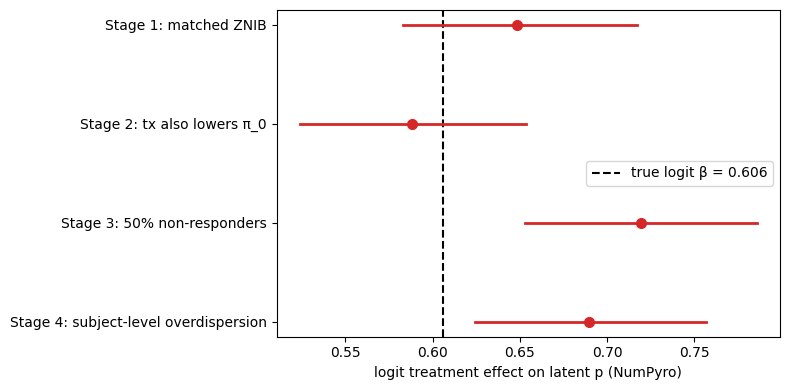

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
true_logit = np.log(0.55 / 0.45) - np.log(0.40 / 0.60)
ax.axvline(true_logit, color='black', ls='--', lw=1.5, label=f'true logit β = {true_logit:.3f}')
for i, (name, fits, em_c, em_t) in enumerate(results):
    f = next(f for f in fits if f['method'] == 'NumPyro ZNI')
    ax.plot([f['tx_logit_ci'][0], f['tx_logit_ci'][1]], [i, i], lw=2, color='#d62728')
    ax.plot(f['tx_logit_mean'], i, 'o', color='#d62728', ms=7)
ax.set_yticks(range(len(results)))
ax.set_yticklabels([r[0] for r in results])
ax.set_xlabel("logit treatment effect on latent p (NumPyro)")
ax.invert_yaxis()
ax.legend()
plt.tight_layout(); plt.show()

## 6. Reading the results

- **Stage 1 (matched).** All three methods give the same marginal
  treatment effect estimate (~0.14) and all cover the empirical
  difference. The naive GLM's logit *coefficient* differs from
  `mznib`'s and from the NumPyro latent β, but their *predicted
  absolute risk differences* agree because the data really is ZNI-Binomial.

- **Stage 2 (treatment also reduces structural zeros) — the headline
  failure mode.** The reminder shrinks the never-engager group from
  20% to 5% **in addition** to lifting the body `p`, so the true
  marginal effect inflates to 0.214. Naive GLM and `mznib` both
  recover this exactly: they are estimating `E[y/N]` directly and do
  not care which mixture component the treatment moves. The NumPyro
  model in this notebook **undershoots to ~0.122** because we wired
  the treatment effect through `p` only and held `π_0` equal across
  arms. The model is misspecified for this data-generating process.
  **This is the case for the marginalized parameterization in a
  nutshell:** if you don't know in advance which sub-mechanism the
  treatment acts on, a model that targets the marginal mean is more
  robust than one that targets a specific latent parameter. To
  recover the right effect with NumPyro you would need to also
  regress `π_0` on `tx`.

- **Stage 3 (50% non-responders).** The marginal effect is genuinely
  smaller (averaged across responders and non-responders, ~0.17).
  All three methods estimate the attenuated marginal effect; none
  flags the heterogeneity. The latent β from NumPyro is similarly
  pulled toward zero — it is reporting a population-average effect
  on the latent `p`, not the responder effect.

- **Stage 4 (subject-level overdispersion) — the second big win for
  `mznib`.** Per-subject `p` is drawn from a Beta around the arm
  mean. Point estimates of the marginal effect are fine for all
  three methods. **The CI widths diverge:**
  naive GLM ≈ 0.030, NumPyro ≈ 0.030, but **`mznib` ≈ 0.088**.
  Only `mznib`'s nonparametric subject-level bootstrap reflects the
  extra variability. The other two condition on a Binomial
  likelihood that has no slack for subject heterogeneity, and report
  intervals that are about three times too tight. An RCT analysis
  that ignores this would substantially overstate its precision.

## 7. Practical recommendations

1. **For a primary RCT readout** (absolute risk difference in
   adherence), `mznib` is the most parsimonious and most robust
   choice. Its marginal target survives both unknown-mechanism
   misspecification (Stage 2) and subject-level overdispersion
   (Stage 4) without modification.
2. **For a mechanism story** ("the reminder works by reducing
   non-engagement"), fit the NumPyro ZNI model with covariates on
   each of `π_0`, `π_N`, and `p` separately. The posterior
   decomposition is what answers "where" the change happened — but
   only if you give the model permission to put it there.
3. **Diagnose before you decide.** All three methods produce
   believable point estimates under every stage above; only the
   *intervals* and *posterior predictive checks* tell you whether
   the model has captured the variability. Report the diagnostic
   alongside the headline number.